In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction.text import CountVectorizer

In [2]:
df = pd.read_csv("emails.csv")

In [3]:
df = pd.read_csv("emails.csv")

print(df.columns)

Index(['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou',
       ...
       'connevey', 'jay', 'valued', 'lay', 'infrastructure', 'military',
       'allowing', 'ff', 'dry', 'Prediction'],
      dtype='str', length=3002)


In [4]:
df.head()

,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


In [5]:
print(df.isnull().sum())

Email No.     0
the           0
to            0
ect           0
and           0
             ..
military      0
allowing      0
ff            0
dry           0
Prediction    0
Length: 3002, dtype: int64


In [6]:
print(df["Prediction"].value_counts())

Prediction
0    3672
1    1500
Name: count, dtype: int64


In [7]:
print(df.isnull().sum().sum())

0


<Axes: xlabel='Prediction', ylabel='count'>

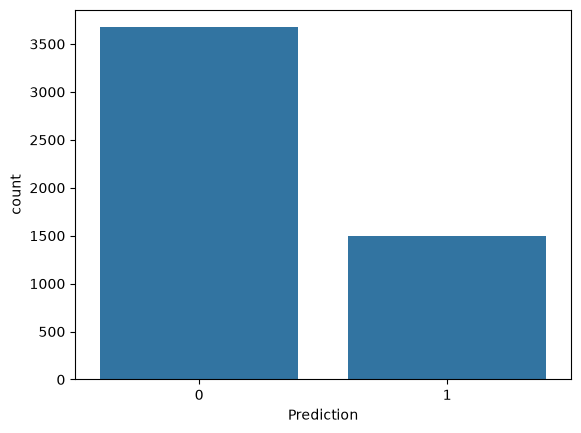

In [9]:
import seaborn as sns

sns.countplot(x=df["Prediction"])

In [10]:
df.info

<bound method DataFrame.info of        Email No.  the  to  ect  and  for  of    a  you  hou  ...  connevey  \
0        Email 1    0   0    1    0    0   0    2    0    0  ...         0   
1        Email 2    8  13   24    6    6   2  102    1   27  ...         0   
2        Email 3    0   0    1    0    0   0    8    0    0  ...         0   
3        Email 4    0   5   22    0    5   1   51    2   10  ...         0   
4        Email 5    7   6   17    1    5   2   57    0    9  ...         0   
...          ...  ...  ..  ...  ...  ...  ..  ...  ...  ...  ...       ...   
5167  Email 5168    2   2    2    3    0   0   32    0    0  ...         0   
5168  Email 5169   35  27   11    2    6   5  151    4    3  ...         0   
5169  Email 5170    0   0    1    1    0   0   11    0    0  ...         0   
5170  Email 5171    2   7    1    0    2   1   28    2    0  ...         0   
5171  Email 5172   22  24    5    1    6   5  148    8    2  ...         0   

      jay  valued  lay  infrast

In [12]:
X = df.drop(["Email No.", "Prediction"], axis=1)
y = df["Prediction"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5172, 3000)
y shape: (5172,)


In [13]:
X

,the,to,ect,and,for,of,a,you,hou,in,...,enhancements,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry
0,0,0,1,0,0,0,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,8,13,24,6,6,2,102,1,27,18,...,0,0,0,0,0,0,0,0,1,0
2,0,0,1,0,0,0,8,0,0,4,...,0,0,0,0,0,0,0,0,0,0
3,0,5,22,0,5,1,51,2,10,1,...,0,0,0,0,0,0,0,0,0,0
4,7,6,17,1,5,2,57,0,9,3,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5167,2,2,2,3,0,0,32,0,0,5,...,0,0,0,0,0,0,0,0,0,0
5168,35,27,11,2,6,5,151,4,3,23,...,0,0,0,0,0,0,0,0,1,0
5169,0,0,1,1,0,0,11,0,0,1,...,0,0,0,0,0,0,0,0,0,0
5170,2,7,1,0,2,1,28,2,0,8,...,0,0,0,0,0,0,0,0,1,0


In [14]:
y

0       0
1       0
2       0
3       0
4       0
       ..
5167    0
5168    0
5169    1
5170    1
5171    0
Name: Prediction, Length: 5172, dtype: int64

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
)

In [16]:
X_train

,the,to,ect,and,for,of,a,you,hou,in,...,enhancements,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry
3164,6,4,2,1,2,8,39,5,2,5,...,0,0,0,0,0,0,0,0,1,0
2067,0,0,1,0,1,0,3,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4717,40,28,4,21,12,12,260,24,4,78,...,0,0,0,0,0,0,0,0,3,0
2505,5,1,1,0,1,1,12,0,0,3,...,0,0,0,0,0,0,0,0,0,0
2268,6,6,3,1,1,0,64,0,1,7,...,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4426,0,3,2,0,2,0,16,0,0,1,...,0,0,0,0,0,0,0,0,0,0
466,4,5,1,0,5,1,28,1,0,1,...,0,0,0,0,0,0,0,0,0,0
3092,0,0,1,0,1,0,5,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3772,2,11,1,6,4,5,58,10,0,12,...,0,0,0,0,0,0,0,0,3,0


In [17]:
X_test

,the,to,ect,and,for,of,a,you,hou,in,...,enhancements,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry
1566,1,1,1,0,1,0,5,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1988,13,20,66,8,10,0,195,4,33,16,...,0,0,0,0,0,0,0,0,0,0
1235,1,14,3,6,2,2,238,0,0,41,...,0,0,1,0,1,0,0,0,5,0
3276,0,0,1,0,1,0,4,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3438,11,6,2,1,5,6,93,3,1,22,...,0,0,0,0,0,0,0,0,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1175,5,3,3,2,3,2,22,1,0,1,...,0,0,0,0,0,0,0,0,0,0
2594,36,25,11,9,9,16,179,4,7,46,...,0,0,0,0,0,0,0,0,3,0
3377,0,0,1,0,1,0,5,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5065,0,1,1,1,0,0,8,1,0,4,...,0,0,0,0,1,0,0,0,0,0


In [18]:
y_test

1566    0
1988    0
1235    1
3276    0
3438    0
       ..
1175    0
2594    0
3377    0
5065    1
2142    0
Name: Prediction, Length: 1035, dtype: int64

In [19]:
y_train

3164    1
2067    0
4717    0
2505    0
2268    0
       ..
4426    0
466     0
3092    0
3772    1
860     1
Name: Prediction, Length: 4137, dtype: int64

In [20]:
model = MultinomialNB()
model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[2933.,1204.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.34,-1.23]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 3000)","[[19579.,17277.,18367.,..., 11., 1980., 21.], [ 7831., 8327., 2939.,..., 7., 1725., 8.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 3000)","[[ -5.06, -5.19, -5.13,...,-12.46, -7.35,-11.85], [ -5.4 , -5.34, -6.38,...,-12.29, -6.91,-12.17]]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3000,)","['the','to','ect',...,'allowing','ff','dry']"


In [21]:
pred = model.predict(X_test)

In [22]:
pred

array([0, 0, 1, ..., 0, 1, 0], shape=(1035,))